In [2]:
import pandas as pd

import matplotlib.pyplot as plt
import matplotlib as mpl

import seaborn as sns

import janitor

In [3]:
generation_data = pd.read_csv('data/release_generation_yearly_global.csv')

generation_data = generation_data.clean_names()

generation_data.info()

<class 'pandas.DataFrame'>
RangeIndex: 104099 entries, 0 to 104098
Data columns (total 24 columns):
 #   Column                                    Non-Null Count   Dtype  
---  ------                                    --------------   -----  
 0   area                                      104099 non-null  str    
 1   iso_3_code                                97833 non-null   str    
 2   year                                      104099 non-null  int64  
 3   area_type                                 104099 non-null  str    
 4   electricity_source                        104099 non-null  str    
 5   is_aggregated_source                      104099 non-null  bool   
 6   generation_twh_                           104099 non-null  float64
 7   generation_yoy_change_twh_                100355 non-null  float64
 8   generation_yoy_change_%_                  66920 non-null   float64
 9   share_of_generation_%_                    104065 non-null  float64
 10  share_of_generation_yoy_change_

In [26]:
# calculate Chinese wind and solar total
generation_data = generation_data[generation_data['area_type'] == 'Country or economy']

generation_data = generation_data[generation_data['year'] == generation_data['year'].max()]

chinese_ws = generation_data.loc[(generation_data['electricity_source'] == 'Wind and solar') & (generation_data['area'] == 'China'), 'generation_twh_'].item()

chinese_ws

2310.39

In [27]:
generation_data = generation_data[(generation_data['electricity_source'] == 'Total generation') | ((generation_data['area'] == 'China') & (generation_data['electricity_source'] == 'Wind and solar'))] 

generation_data = generation_data[(generation_data['area'] != 'China') | (generation_data['electricity_source'] != 'Total generation')]

generation_data = generation_data.sort_values(by='generation_twh_', ascending=False, na_position='first').reset_index(drop=True)

(50.0, 5000.0)

c:\Users\user\Documents\Projects\2026\chinaEnergy\venv\Lib\site-packages\seaborn\categorical.py:3399: UserWarning: 15.4% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)


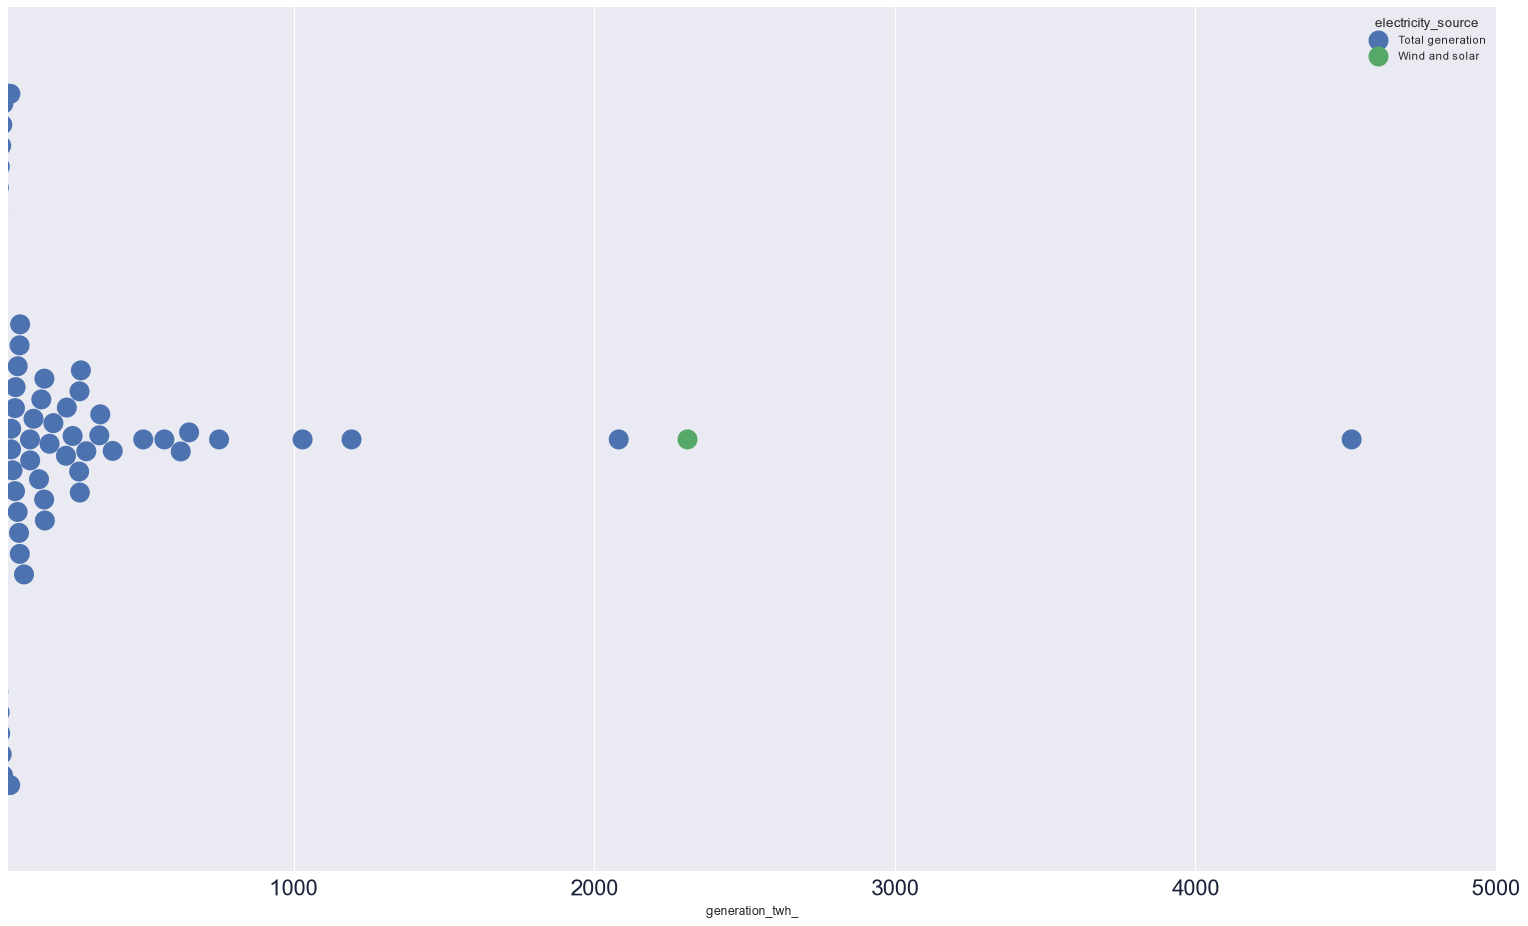

In [ ]:
# create beeswarm plot
background = '#f5f7fa'
text_colour = '#192238'

# equivalent to R themes() for quick styling
plt.style.use('seaborn-v0_8')

# call specific elements to update theme
mpl.rcParams['xtick.color'] = text_colour
mpl.rcParams['xtick.labelsize'] = '20'

fig, ax = plt.subplots(figsize=(1920, 1080, 'px'))

# ax.set(xscale="log")
sns.swarmplot(x='generation_twh_', data=generation_data, size=18, hue='electricity_source')

# ax.set_xlim(50, 5000)


In [8]:
print(plt.style.available)

['Solarize_Light2', 'bmh', 'classic', 'dark_background', 'fast', 'fivethirtyeight', 'ggplot', 'grayscale', 'petroff10', 'petroff6', 'petroff8', 'seaborn-v0_8', 'seaborn-v0_8-bright', 'seaborn-v0_8-colorblind', 'seaborn-v0_8-dark', 'seaborn-v0_8-dark-palette', 'seaborn-v0_8-darkgrid', 'seaborn-v0_8-deep', 'seaborn-v0_8-muted', 'seaborn-v0_8-notebook', 'seaborn-v0_8-paper', 'seaborn-v0_8-pastel', 'seaborn-v0_8-poster', 'seaborn-v0_8-talk', 'seaborn-v0_8-ticks', 'seaborn-v0_8-white', 'seaborn-v0_8-whitegrid', 'tableau-colorblind10']
